In [2]:
# 电商用户价值分析与流失预测

## 项目背景
#基于英国电商数据集（Online Retail II），使用 RFM 模型对用户分层，并构建逻辑回归流失预测模型。

In [4]:
#导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置 matplotlib 中文字体，防止图表中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']   # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False     # 用来正常显示负号

In [5]:
# 1. 数据加载与初步探索
# ------------------------------

# 读取 Excel 文件中的 'Year 2010-2011' 工作表
df = pd.read_excel(r"C:\Users\chen\Downloads\online_retail_II.xlsx\online_retail_II.xlsx", sheet_name='Year 2010-2011')
print(df.info())                     # 打印数据结构（行数、列数、类型、非空数量）
print("列名：", df.columns.tolist()) # 打印所有列名

# 查看前10行数据（不限制显示列数）
with pd.option_context('display.max_columns', None):
    print(df.head(10))

# 查看所有数值列的描述性统计（包括非数值列）
print(df.describe(include='all'))

# 查看各列缺失值数量
print("\n缺失值统计：")
print(df.isnull().sum())

# 查看 Customer ID 缺失的行（随机5条）
print("\n缺失Customer ID的样本：")
print(df[df['Customer ID'].isnull()].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None
列名： ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN 

In [6]:
# 2. 数据清洗
# ------------------------------

# 删除 Customer ID 为空的行（无法进行用户分析）
df = df.dropna(subset=['Customer ID'])

# 只保留购买数量 >0 且单价 >0 的记录（剔除退货和无效数据）
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# 新增销售额列（数量 × 单价）
df['Sales'] = df['Quantity'] * df['Price']

# 用 'Unknown' 填充商品描述中的缺失值
df['Description'] = df['Description'].fillna('Unknown')

# 打印清洗后的记录数和数据结构
print(f"清洗后记录数：{len(df)}")
print(df.info())

清洗后记录数：397885
<class 'pandas.core.frame.DataFrame'>
Index: 397885 entries, 0 to 541909
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      397885 non-null  object        
 1   StockCode    397885 non-null  object        
 2   Description  397885 non-null  object        
 3   Quantity     397885 non-null  int64         
 4   InvoiceDate  397885 non-null  datetime64[ns]
 5   Price        397885 non-null  float64       
 6   Customer ID  397885 non-null  float64       
 7   Country      397885 non-null  object        
 8   Sales        397885 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB
None


In [7]:
# 3. RFM 指标计算
# ------------------------------

# 获取数据中最后一条订单的日期，作为计算 R（最近购买天数）的基准
snapshot_date = df['InvoiceDate'].max()
print("快照日期（数据截止日）：", snapshot_date)

# 按客户ID分组，计算每个客户的 R、F、M
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,   # R：最近购买距今天数
    'Invoice': 'nunique',                                      # F：不同订单号数量（购买次数）
    'Sales': 'sum'                                             # M：总消费金额
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'Sales': 'Monetary'
})

# 查看 RFM 原始值的前几行
print("RFM 原始值：")
print(rfm.head())

快照日期（数据截止日）： 2011-12-09 12:50:00
RFM 原始值：
             Recency  Frequency  Monetary
Customer ID                              
12346.0          325          1  77183.60
12347.0            1          7   4310.00
12348.0           74          4   1797.24
12349.0           18          1   1757.55
12350.0          309          1    334.40


In [8]:
# 4. RFM 打分（1-4分）
# ------------------------------

# R 得分：天数越小越好，所以逆序分箱（最近购买的得4分，最久的得1分）
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1]).astype(int)

# F 得分：频率越高越好，顺序分箱。先用 rank 处理重复值，避免分箱错误
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)

# M 得分：金额越高越好，顺序分箱
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4]).astype(int)

# 将三个分数拼接成字符串，例如 "444"
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

Level
低价值    2688
中价值    1160
高价值     490
Name: count, dtype: int64
Level
低价值    0.619640
中价值    0.267404
高价值    0.112955
Name: proportion, dtype: float64
高价值用户贡献销售额占比：49.8%


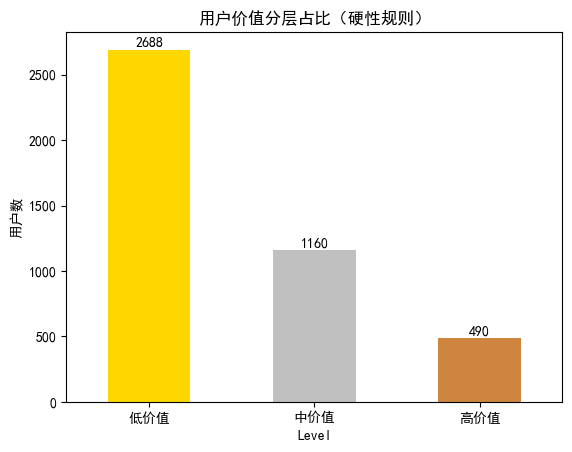

原始数据中不同客户数（清洗后）： 4338
RFM 表中客户数： 4338


In [9]:
# 5. 基于 RFM 总分的用户分层（硬性规则）
# ------------------------------

def rfm_level(score):
    s = int(score)          # 字符串转整数
    if s >= 444:            # 三项都是最高分
        return '高价值'
    elif s >= 333:          # 至少三项都是中等以上
        return '中价值'
    else:
        return '低价值'

rfm['Level'] = rfm['RFM_score'].apply(rfm_level)

# 打印各层级人数和占比
print(rfm['Level'].value_counts())
print(rfm['Level'].value_counts(normalize=True))

# 计算并打印高价值用户（按硬性规则）贡献的销售额占比
high_value_sales = rfm[rfm['Level'] == '高价值']['Monetary'].sum()
total_sales = rfm['Monetary'].sum()
print(f"高价值用户贡献销售额占比：{high_value_sales/total_sales:.1%}")

# 绘制用户分层柱状图（硬性规则）
level_counts = rfm['Level'].value_counts()
ax = level_counts.plot(kind='bar', color=['gold', 'silver', 'peru'])
for i, v in enumerate(level_counts):
    ax.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=10)
plt.title('用户价值分层占比（硬性规则）')
plt.ylabel('用户数')
plt.xticks(rotation=0)
plt.show()

# 打印清洗后的客户总数和 RFM 表中的客户数（应相等）
print("原始数据中不同客户数（清洗后）：", df['Customer ID'].nunique())
print("RFM 表中客户数：", len(rfm))

高价值用户贡献占比：66.3%


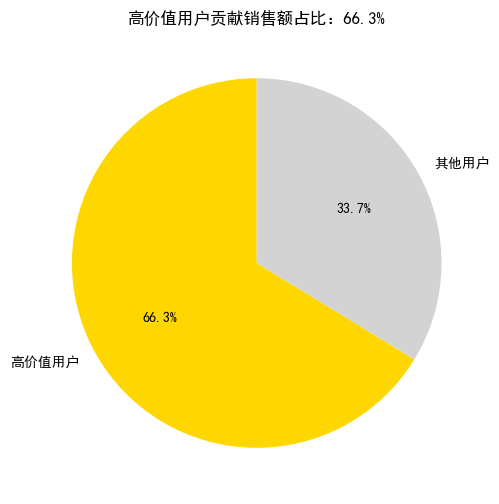

In [10]:
# 6. 改用综合得分前20% 定义高价值用户（更符合二八原则）
# ------------------------------

# 计算 R、F、M 得分之和
rfm['Total_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']
# 取总分前 20% 的阈值（80% 分位数）
threshold = rfm['Total_Score'].quantile(0.8)
# 初始化为普通用户
rfm['Level'] = '普通用户'
# 总分大于等于阈值的标记为高价值用户
rfm.loc[rfm['Total_Score'] >= threshold, 'Level'] = '高价值用户'

# 计算高价值用户（前20%）贡献的销售额占比
high_sales = rfm[rfm['Level'] == '高价值用户']['Monetary'].sum()
total_sales = rfm['Monetary'].sum()
print(f"高价值用户贡献占比：{high_sales/total_sales:.1%}")

# 绘制饼图展示贡献占比
sizes = [high_sales, total_sales - high_sales]
labels = ['高价值用户', '其他用户']
colors = ['gold', 'lightgray']
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'高价值用户贡献销售额占比：{high_sales/total_sales:.1%}')
plt.show()

高价值用户最爱商品 Top 10：
Description
REGENCY CAKESTAND 3 TIER              107231.55
WHITE HANGING HEART T-LIGHT HOLDER     66317.75
JUMBO BAG RED RETROSPOT                64861.96
RABBIT NIGHT LIGHT                     45459.41
POSTAGE                                45270.72
PARTY BUNTING                          43920.03
CHILLI LIGHTS                          40070.81
ASSORTED COLOUR BIRD ORNAMENT          38969.69
BLACK RECORD COVER FRAME               32076.80
JUMBO BAG PINK POLKADOT                30806.61
Name: Sales, dtype: float64


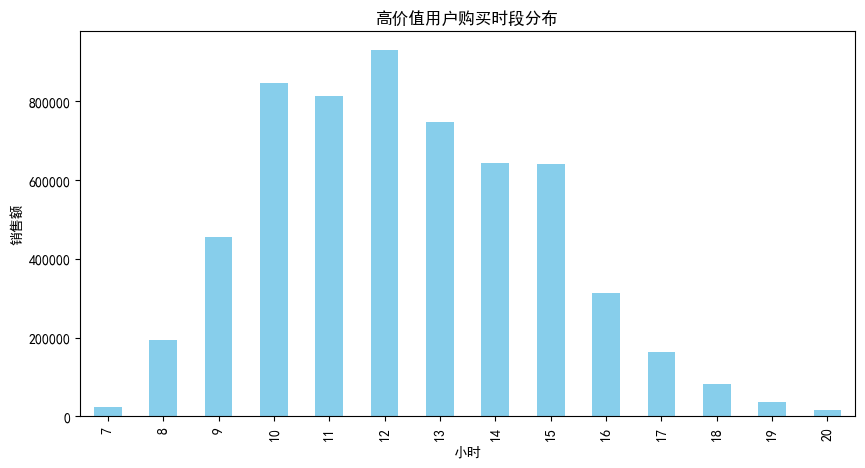

In [11]:
# 7. 高价值用户画像分析
# ------------------------------

# 获取高价值用户的客户ID
high_ids = rfm[rfm['Level'] == '高价值用户'].index
# 从原始交易数据中筛选出这些用户的记录（注意 copy 避免警告）
high_df = df[df['Customer ID'].isin(high_ids)].copy()

# 高价值用户最爱商品 Top 10（按销售额）
top_products = high_df.groupby('Description')['Sales'].sum().sort_values(ascending=False).head(10)
print("高价值用户最爱商品 Top 10：")
print(top_products)

# 提取订单中的小时，分析购买时段分布
high_df['Hour'] = high_df['InvoiceDate'].dt.hour
hourly = high_df.groupby('Hour')['Sales'].sum()
hourly.plot(kind='bar', figsize=(10,5), color='skyblue')
plt.title('高价值用户购买时段分布')
plt.xlabel('小时')
plt.ylabel('销售额')
plt.show()

In [12]:
#流失预测
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. 定义流失标签
rfm['IsChurn'] = (rfm['Recency'] > 90).astype(int)
print(f"流失用户占比：{rfm['IsChurn'].mean():.2%}")

# 2. 准备特征
features = ['R_score', 'F_score', 'M_score']
X = rfm[features]
y = rfm['IsChurn']

# 3. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. 训练逻辑回归
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. 预测与评估
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("\n=== 模型评估 ===")
print(classification_report(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

# 6. 特征系数
coef_df = pd.DataFrame({'feature': features, 'coef': model.coef_[0]})
print("\n特征系数（绝对值越大影响越大）：")
print(coef_df.sort_values('coef', key=abs, ascending=False))

# 7. 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
print("\n混淆矩阵：")
print(cm)
# 导出用户级 RFM 表（包含分层、流失标签等）
rfm_export = rfm.reset_index()  # 把 Customer ID 从索引变成普通列
rfm_export.to_csv('rfm_user_data.csv', index=False)

流失用户占比：33.31%

=== 模型评估 ===
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       867
           1       1.00      0.74      0.85       435

    accuracy                           0.91      1302
   macro avg       0.94      0.87      0.89      1302
weighted avg       0.92      0.91      0.91      1302

AUC: 0.970

特征系数（绝对值越大影响越大）：
   feature      coef
0  R_score -5.739563
2  M_score -0.276119
1  F_score  0.157052

混淆矩阵：
[[867   0]
 [115 320]]


In [13]:
# 导出销售明细表
sales_export = df[['InvoiceDate', 'Customer ID', 'Sales', 'Description']].copy()
sales_export.to_csv('sales_detail_full.csv', index=False)

print("数据已导出为 CSV 文件，保存在当前工作目录。")

数据已导出为 CSV 文件，保存在当前工作目录。
